# Itau Quant Challenge 2025 - Pipeline End-to-End

Este notebook executa o processo completo do repositorio, explicando cada etapa e salvando artefatos em `reports/`.

Etapas:
- Carregar configuracao e dados
- Rodar backtest base e exibir KPIs
- Walk-forward validation
- Heatmaps de sensibilidade de parametros
- Stress de custos de transacao
- Capacity curve
- (Opcional) PDF consolidado do relatorio


In [1]:
# Setup
from pathlib import Path
import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

import os; os.environ["REGIME_GAIN"] = "2"
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'src').exists(), 'Execute a partir do repo root ou da pasta notebooks/'
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
%matplotlib inline

REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
print('Repo root:', ROOT)
print('Reports dir:', REPORTS_DIR)

Repo root: d:\GitHub Dic\itau-quant-challenge-2025
Reports dir: d:\GitHub Dic\itau-quant-challenge-2025\reports


## Configuracao
Carrega o YAML de configuracao base do projeto.

In [2]:
from dataio.config import load_config

CONFIG_PATH = ROOT / 'configs' / 'base.yaml'
cfg = load_config(str(CONFIG_PATH))
print('Config carregada:', CONFIG_PATH)
print('Datas:', cfg.get('dates'))
cfg

Config carregada: d:\GitHub Dic\itau-quant-challenge-2025\configs\base.yaml
Datas: {'start': datetime.date(2019, 1, 4), 'end': datetime.date(2022, 12, 2)}


{'portfolio': {'method': 'hrp'},
 'data': {'source': 'local_csv'},
 'paths': {'data': './data',
  'reports': './reports',
  'artifacts': './artifacts'},
 'seeds': 42,
 'dates': {'start': datetime.date(2019, 1, 4),
  'end': datetime.date(2022, 12, 2)},
 'tda': {'delay': 1,
  'dim': 3,
  'n_cubes': 4,
  'overlap': 0.95,
  'epsilon': None,
  'min_samples': 2,
  'window': 126},
 'factors': {'alphas': ['momentum', 'quality', 'carry'],
  'softmax_T': 1.1,
  'regime_gain': 2.0,
  'alpha': 0.5,
  'beta': 0.3,
  'gamma': 0.1},
 'windows': {'vol_window': 60, 'atr_len': 14},
 'costs': {'fee_bps': 5.0, 'k': 0.1, 'max_bps': 50.0},
 'participation_cap': 0.05,
 'turnover_cap': 1.0,
 'vol_target': 0.1,
 'universe': {'top_n': 20,
  'adv_min': 500000.0,
  'price_min': 5.0,
  'age_min': 20,
  'hysteresis_rebalances': 2,
  'calendar': 'BME'},
 'validation': {'param_grid': {'delay': [1, 2],
   'dim': [3],
   'n_cubes': [3, 4, 6],
   'overlap': [0.8, 1.0],
   'alpha': [0.5, 0.6],
   'beta': [0.3],
   'gamma

## Dados
Carrega o painel de mercado. Se o `get_panel` falhar, cai para dados sinteticos. Exibe um preview e o intervalo de datas.

In [3]:
from main import _load_panel as _load_panel

panel = _load_panel(cfg)
date_level = 'date' if 'date' in panel.index.names else panel.index.names[0]
print('Panel shape:', panel.shape)
print('Date range:', panel.index.get_level_values(date_level).min(), '->', panel.index.get_level_values(date_level).max())
panel.sort_index().head()

Panel shape: (59923, 2)
Date range: 2019-01-04 00:00:00 -> 2022-12-02 00:00:00


close       volume
date       asset                    
2019-01-04 ABEV3  16.55  453335332.0
           B3SA3  27.95  620041674.0
           BBAS3  48.80  431765865.0
           BBDC3  35.70  166120321.0
           BBDC4  40.46  606268108.0

## Backtest Base
Executa o backtest principal, plota a equity e salva artefatos em `reports/`.

Skipping rebalance on 2019-03-29 due to missing covariance
Kill switch triggered on 2020-01-31


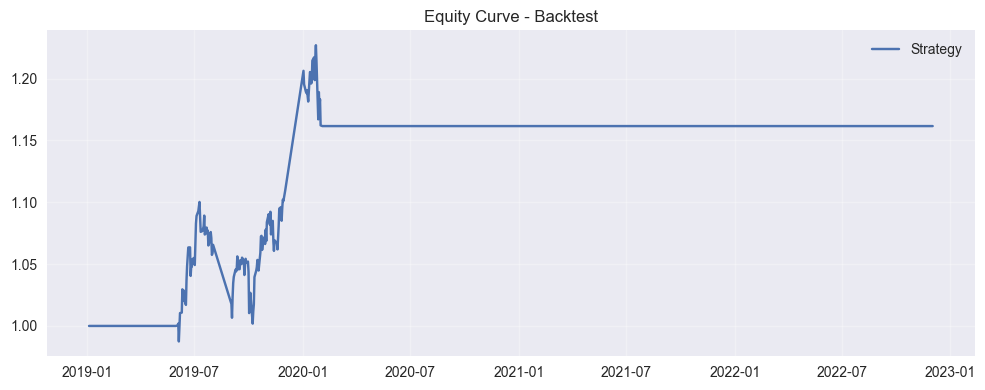

**KPIs - Backtest**

,CAGR,Sharpe,Sortino,Vol,MaxDD,Calmar,HitRate,Turnover
Strategy,0.05114,0.611091,0.386011,0.087981,-0.089426,0.571872,0.584615,0.002398


Equity curve salva em: D:\GitHub Dic\itau-quant-challenge-2025\reports\equity_curve_full.png


In [4]:
from backtest.engine import run_backtest
from reports import plot_equity_curves, table_kpis

bt = run_backtest(cfg, panel=panel)
equity = bt['equity_curve']
returns = equity.pct_change().dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(equity.index, equity.values, label='Strategy')
ax.set_title('Equity Curve - Backtest')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

kpi = table_kpis({
    'Strategy': {
        'equity_curve': equity,
        'returns': returns,
        'weights': bt.get('daily_positions')
    }
})
display(Markdown('**KPIs - Backtest**'))
display(kpi)

equity_png = plot_equity_curves({'Strategy': equity}, filename='equity_curve_full.png')
print('Equity curve salva em:', equity_png)

,value
CAGR_Strategy,0.051140
CAGR_Ibov,0.068049
Excess_CAGR,-0.016909
Alpha_ann,0.045712
Beta,0.067501
TrackingError,0.311357
InformationRatio,-0.207294
MaxDD_Strategy,-0.089426
MaxDD_Ibov,-0.468160
MonthlyHitRate,0.437500


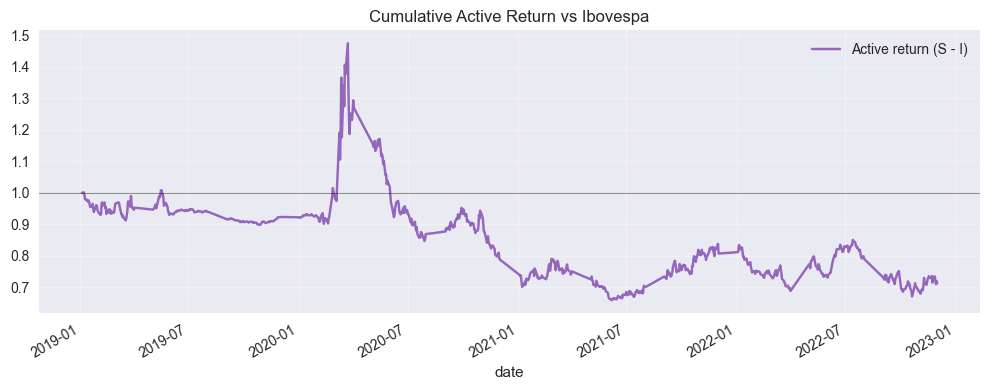

In [5]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

# 1) Alinhar calendários
project_root = Path.cwd().resolve().parent  # inside notebooks/
ibov_path = project_root / "data" / "benchmark" / "ibovespa_index_b3.csv"
ibov_series = (
    pd.read_csv(ibov_path, parse_dates=["date"], index_col="date")["close"]
    .sort_index()
)
idx = equity.index.intersection(ibov_series.index)
eq = equity.loc[idx].ffill()
ib = ibov_series.loc[idx].ffill()

# 2) Retornos diários
r_s = eq.pct_change().fillna(0.0)
r_b = ib.pct_change().fillna(0.0)
r_ex = r_s - r_b  # retorno ativo

# 3) Métricas principais (252 dias úteis/ano)
ann = 252
te = r_ex.std(ddof=0) * np.sqrt(ann)
ir = (r_ex.mean() / r_ex.std(ddof=0)) * np.sqrt(ann) if r_ex.std(ddof=0) > 0 else np.nan
beta = (r_s.cov(r_b) / r_b.var()) if r_b.var() > 0 else np.nan
alpha_ann = (r_s.mean() - beta * r_b.mean()) * ann if beta==beta else np.nan

cagr_s = (eq.iloc[-1] / eq.iloc[0]) ** (ann / len(r_s)) - 1
cagr_b = (ib.iloc[-1] / ib.iloc[0]) ** (ann / len(r_b)) - 1
dd_s = (eq / eq.cummax() - 1.0).min()
dd_b = (ib / ib.cummax() - 1.0).min()
hit_m = (r_s.resample('M').sum() > r_b.resample('M').sum()).mean()

summary = pd.Series({
    'CAGR_Strategy': cagr_s,
    'CAGR_Ibov': cagr_b,
    'Excess_CAGR': cagr_s - cagr_b,
    'Alpha_ann': alpha_ann,
    'Beta': beta,
    'TrackingError': te,
    'InformationRatio': ir,
    'MaxDD_Strategy': dd_s,
    'MaxDD_Ibov': dd_b,
    'MonthlyHitRate': hit_m,
}).to_frame('value')
display(summary)

# 4) Curva de retorno ativo (mostra se bateu no acumulado)
active_curve = (1.0 + r_ex).cumprod()
ax = active_curve.plot(figsize=(10, 4), color='tab:purple', label='Active return (S - I)')
ax.axhline(1.0, color='black', lw=0.8, alpha=0.4)
ax.set_title('Cumulative Active Return vs Ibovespa')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## Walk-Forward Validation
Executa validacao walk-forward (2 anos in-sample / 6 meses out-of-sample). Mostra equity e KPIs agregados.

Skipping rebalance on 2019-03-29 due to missing covariance
Kill switch triggered on 2020-01-31
Kill switch triggered on 2020-01-31


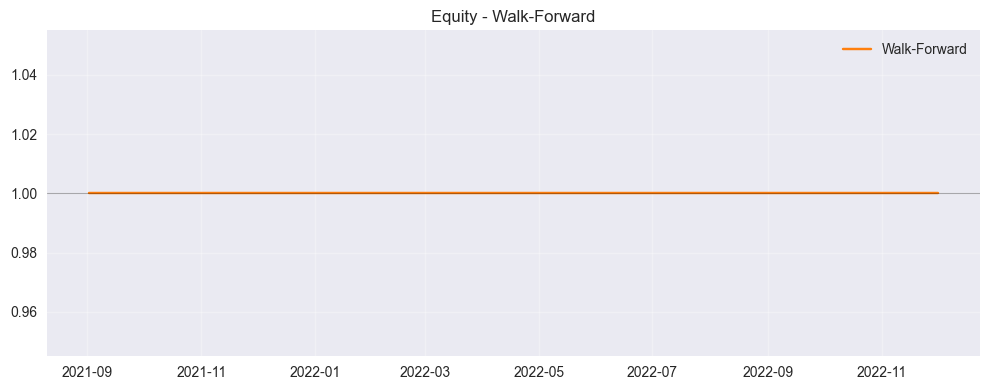

**KPIs - Walk-Forward**

,Valor
CAGR,0.0
Sharpe,NaN
Sortino,NaN
Vol,0.0
MaxDD,0.0
Calmar,NaN
HitRate,NaN
Turnover,0.0


**Janelas Walk-Forward (amostra)**

,is_start,is_end,oos_start,oos_end,kpis,config
0,2019-01-04,2021-08-02,2021-09-02,2022-05-02,"{'final_equity': 1.161629894310117, 'total_ret...","{'alphas': ['momentum', 'quality', 'carry'], '..."
1,2019-09-04,2022-05-02,2022-05-03,2022-12-01,"{'final_equity': 1.0414339554947964, 'total_re...","{'alphas': ['momentum', 'quality', 'carry'], '..."


In [6]:
from validation import run_walk_forward

wf = run_walk_forward(cfg, panel)
walk_equity = wf['equity_curve']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(walk_equity.index, walk_equity.values, color='#ff7f0e', label='Walk-Forward')
ax.axhline(1.0, color='black', linewidth=0.8, alpha=0.3)
ax.set_title('Equity - Walk-Forward')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown('**KPIs - Walk-Forward**'))
display(pd.DataFrame(wf['kpis'], index=['Valor']).T)

windows_df = pd.DataFrame(wf['windows'])
display(Markdown('**Janelas Walk-Forward (amostra)**'))
display(windows_df.head())

## Heatmaps de Sensibilidade
Gera heatmaps para o grid configurado em `validation.robustness_grid`. Se as figuras sairem em cor unica, considere variar `epsilon`, `n_cubes` e `overlap` tambem.

In [7]:
# from validation import param_sensitivity_heatmaps

# grid = cfg.get('validation', {}).get('robustness_grid')
# if grid:
#     heat_paths = param_sensitivity_heatmaps(cfg, panel, grid)
#     display(Markdown('**Heatmaps gerados:**'))
#     for p in heat_paths:
#         display(Image(filename=str(p)))
# else:
#     print('Nenhum robustness_grid definido em configs.')

## Stress de Custos
Escalona as premissas de custos (`fee_bps`, `k`, `max_bps`) pelos multiplicadores em `validation.stress_multipliers`.

In [8]:
# from validation import stress_costs

# mults = cfg.get('validation', {}).get('stress_multipliers', [0.5, 1.0, 1.5])
# stress_csv = stress_costs(cfg, panel, multipliers=mults)
# print('CSV salvo em:', stress_csv)
# display(pd.read_csv(stress_csv))

## Capacity Curve
Avalia a sensibilidade de Sharpe, MaxDD e Turnover ao `participation_cap`.

Skipping rebalance on 2019-03-29 due to missing covariance
Kill switch triggered on 2019-07-31
Skipping rebalance on 2019-03-29 due to missing covariance
Kill switch triggered on 2019-09-30
Skipping rebalance on 2019-03-29 due to missing covariance
Kill switch triggered on 2020-01-31
Skipping rebalance on 2019-03-29 due to missing covariance
Kill switch triggered on 2020-01-31
Skipping rebalance on 2019-03-29 due to missing covariance
Kill switch triggered on 2020-01-31
Skipping rebalance on 2019-03-29 due to missing covariance
Kill switch triggered on 2020-01-31
Skipping rebalance on 2019-03-29 due to missing covariance
Kill switch triggered on 2020-01-31
Skipping rebalance on 2019-03-29 due to missing covariance
Kill switch triggered on 2020-01-31


Artefatos: {'csv': WindowsPath('D:/GitHub Dic/itau-quant-challenge-2025/reports/capacity_curve_20250928_072133.csv'), 'figure': WindowsPath('D:/GitHub Dic/itau-quant-challenge-2025/reports/capacity_curve_20250928_072133.png')}


,participation_cap,Sharpe,MaxDD,Turnover,cap_bind_rate,avg_turnover_cut_frac,MaxDD_pos
0,0.01,0.620407,-0.052014,0.002302,1.0,0.402068,0.052014
1,0.02,0.623564,-0.100305,0.002449,1.0,0.620199,0.100305
2,0.03,0.862478,-0.058954,0.003075,1.0,0.789168,0.058954
3,0.04,0.660697,-0.084528,0.002542,1.0,0.810297,0.084528
4,0.05,0.611091,-0.089426,0.002398,1.0,0.813904,0.089426
5,0.06,0.585786,-0.090383,0.002435,1.0,0.813110,0.090383
6,0.07,0.579888,-0.088664,0.002533,1.0,0.811068,0.088664
7,1.00,0.568746,-0.090627,0.002880,0.0,0.801400,0.090627


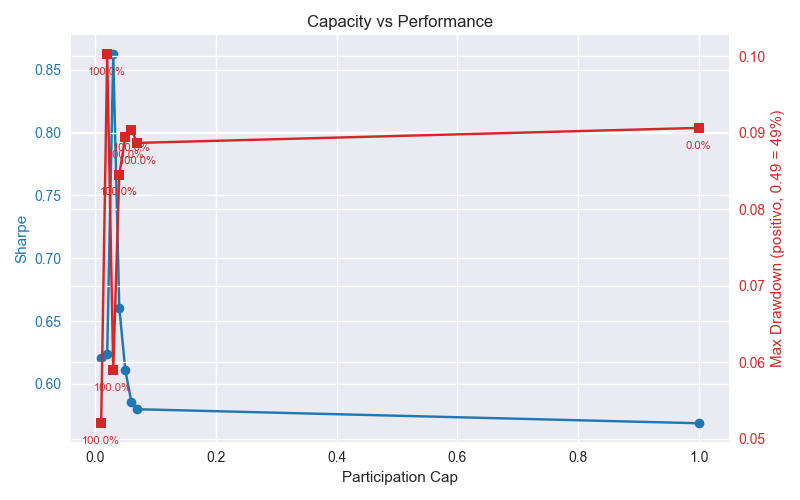

In [9]:
from validation import capacity_curve

caps = cfg.get('validation', {}).get('participation_caps', [0.01, 0.015, 0.02, 0.03, 0.05, 0.07, 0.10, 0.15])
capacity_out = capacity_curve(cfg, panel, participation_caps=caps)
print('Artefatos:', capacity_out)
cap_df = pd.read_csv(capacity_out['csv'])
display(cap_df)
display(Image(filename=str(capacity_out['figure'])))

## Relatorio PDF (Opcional)
Gera um PDF consolidado com figuras e caminhos dos artefatos.

In [10]:
# from reports.build_pdf import build_pdf
# 
# pdf_out = REPORTS_DIR / 'consolidated_report.pdf'
# build_pdf(CONFIG_PATH, pdf_out)
# print('PDF salvo em:', pdf_out)

## Proximos Passos
- Ajuste o grid de robustez (ex.: incluir `epsilon`, `n_cubes`, `overlap`).
- Tente diferentes periodos e universos no YAML.
- Compare estrategias alterando `factors.alphas` para diferentes pesos.
